# Desafio AutoCred — análise exploratória dirigida

**Contexto.** A AutoCred é uma fintech de financiamento de veículos que cresceu desde 2022 com
uma política de concessão nunca revisada. Em 2024 a inadimplência estourou o planejado. Este
notebook é a etapa de diagnóstico de um projeto que precisa entregar dois produtos: um **modelo
de probabilidade de inadimplência (PD)** e uma **política de crédito** avaliada por retorno.

**Esta não é uma exploração aberta.** São três perguntas cujas respostas mudam o que o pipeline
vai fazer — e só elas:

1. **Quais variáveis têm poder preditivo, e como agrupá-las em faixas?**
2. **O valor ausente carrega informação?** Se carregar, a ausência vira variável em vez de ser
   imputada em silêncio.
3. **A relação entre cada variável e a inadimplência é monotônica?** A política final opera em
   faixas de score de 1 a 10; relação que sobe e desce produz faixa indefensável.

Histograma, boxplot e matriz de correlação ficaram de fora de propósito. Exploração que não muda
uma decisão é tempo gasto sem contrapartida.

> **A regra que quase todo mundo viola aqui.** Todas as decisões são calculadas na janela de
> **treino (2022-2023)**. A safra de 2024 aparece só para conferir estabilidade, nunca para
> decidir. Escolher variáveis olhando a base inteira contamina a validação *out-of-time*: o
> modelo passa a ser avaliado num período que já influenciou quais variáveis ele usa.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

RAIZ = Path.cwd().parent
sys.path.insert(0, str(RAIZ / "src"))

from dados import ALVO, CANDIDATAS, CATEGORICAS, carregar_base_a, carregar_base_c, mapear_base_c
from exploracao import AUSENTE, binar, classificar_psi, pd_com_ic, resumo_variaveis, tabela_woe

ANO_CORTE = 2024

AZUL, LARANJA, VERMELHO = "#2a78d6", "#eb6834", "#e34948"
NEUTRO, TINTA, SECUNDARIA, EIXO, GRADE = "#f0efec", "#0b0b0b", "#52514e", "#c3c2b7", "#e1e0d9"
RAMPA_AZUL = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#2a78d6", "#1c5cab", "#104281"]

plt.rcParams.update({
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": EIXO, "axes.labelcolor": SECUNDARIA, "axes.titlecolor": TINTA,
    "axes.grid": True, "grid.color": GRADE, "grid.linewidth": 0.8,
    "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": SECUNDARIA, "ytick.color": SECUNDARIA,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
    "figure.dpi": 110, "savefig.bbox": "tight",
})
pd.set_option("display.width", 120)
print("ambiente pronto")

ambiente pronto


## As três bases

| Base | Linhas | Período | Papel |
|---|---:|---|---|
| A — desenvolvimento | 10.000 | 2022-01 a 2024-12 | treino; tem o alvo |
| B — teste do modelo | 3.000 | 2025-01 a 2025-06 | teste *out-of-time*, **sem alvo** |
| C — política | 5.000 | 2025-07 a 2025-12 | propostas que recebem a política |

A diferença decisiva: **A e B só contêm contratos que a política antiga aprovou.** A Base C é mar
aberto — inclui perfis que a AutoCred recusava. O modelo aprende numa população e será aplicado
em outra, maior.

In [2]:
a = carregar_base_a()
treino = a[a["ano"] < ANO_CORTE]
conferencia = a[a["ano"] == ANO_CORTE]
base_c = mapear_base_c(carregar_base_c())

print(f"treino      n={len(treino):>6,}  PD={treino[ALVO].mean():.4f}")
print(f"conferência n={len(conferencia):>6,}  PD={conferencia[ALVO].mean():.4f}")
print(f"aplicação   n={len(base_c):>6,}  (sem alvo — é onde a política será aplicada)")

a.groupby("ano")[ALVO].agg(contratos="size", PD="mean").round(4)

treino      n= 6,670  PD=0.0880
conferência n= 3,330  PD=0.0718
aplicação   n= 5,000  (sem alvo — é onde a política será aplicada)


,contratos,PD
ano,,
2022,3380,0.0867
2023,3290,0.0894
2024,3330,0.0718


## Pergunta 1 — quais variáveis predizem?

Duas medidas fazem o trabalho, e as duas partem da mesma ideia.

**WoE** (*weight of evidence*) mede, dentro de um grupo de contratos, o quanto bons e maus
pagadores estão desproporcionalmente representados:

$$\text{WoE} = \ln\left(\frac{\%\ \text{dos bons neste bin}}{\%\ \text{dos maus neste bin}}\right)$$

WoE positivo = mais bons que a média. Negativo = mais maus. Zero = o bin não distingue nada.

**IV** (*information value*) soma essa evidência sobre todos os bins e resume a variável num número:

$$\text{IV} = \sum_{bins} (\%\text{bons} - \%\text{maus}) \times \text{WoE}$$

Régua usada no mercado de crédito — convenção difundida, não norma: abaixo de 0,02 inútil; até
0,10 fraco; até 0,30 médio; até 0,50 forte. **Acima de 0,50, suspeite de vazamento** em vez de
comemorar.

Os ausentes viram um bin próprio (`AUSENTE`) em vez de serem imputados antes — é isso que permite
responder à pergunta 2 mais adiante.

In [3]:
resumo, tabelas = resumo_variaveis(treino, conferencia, base_c, CANDIDATAS, CATEGORICAS, ALVO)

resumo[["variável", "IV_treino", "IV_conferencia", "força", "rho", "inversões", "PSI_aplicacao"]].round(
    {"IV_treino": 4, "IV_conferencia": 4, "rho": 2, "PSI_aplicacao": 3}
)

,variável,IV_treino,IV_conferencia,força,rho,inversões,PSI_aplicacao
0,score_bureau,0.1731,0.2864,médio,-0.79,1,0.488
1,qtd_restricoes_ativas,0.1328,0.1083,médio,1.00,0,2.335
2,idade_cliente,0.1171,0.1599,médio,-0.61,4,0.003
3,renda_mensal_declarada,0.1125,0.1697,médio,-0.90,5,0.141
4,prazo_meses,0.0773,0.0586,fraco,1.00,0,0.003
5,valor_entrada,0.0590,0.0612,fraco,-0.65,4,0.111
6,valor_bem,0.0545,0.0477,fraco,-0.95,4,0.040
7,comprometimento_renda,0.0503,0.1330,fraco,0.41,3,NaN
8,valor_financiado,0.0486,0.0209,fraco,-0.80,6,0.009
9,ocupacao,0.0469,0.0375,fraco,-0.80,3,0.002


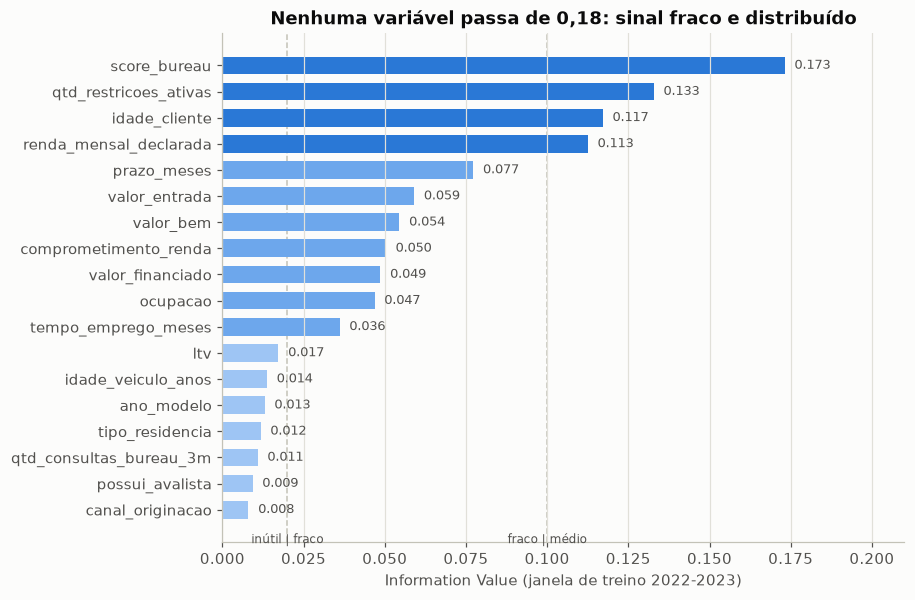

In [4]:
# Codificação sequencial: a força do IV é uma classe ordenada, então recebe uma
# rampa de um só tom (claro -> escuro). Nada de cor categórica para ordem.
ordem_forca = ["inútil", "fraco", "médio", "forte"]
tom = {"inútil": RAMPA_AZUL[1], "fraco": RAMPA_AZUL[2], "médio": RAMPA_AZUL[4], "forte": RAMPA_AZUL[6]}

d = resumo.sort_values("IV_treino")
fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(d["variável"], d["IV_treino"], color=[tom[f] for f in d["força"]], height=0.68)
for limite, rotulo in [(0.02, "inútil | fraco"), (0.10, "fraco | médio")]:
    ax.axvline(limite, color=EIXO, lw=1, ls="--", zorder=0)
    ax.text(limite, -0.9, rotulo, ha="center", va="top", fontsize=8, color=SECUNDARIA)
for y, (v, nome) in enumerate(zip(d["IV_treino"], d["variável"])):
    ax.text(v + 0.003, y, f"{v:.3f}", va="center", fontsize=8.5, color=SECUNDARIA)
ax.set_xlim(0, 0.21)
ax.set_xlabel("Information Value (janela de treino 2022-2023)")
ax.set_title("Nenhuma variável passa de 0,18: sinal fraco e distribuído")
ax.grid(axis="y", visible=False)
plt.show()

**Leitura.** Não existe variável dominante. O IV somado das 18 é 0,99, e a maior isolada é 0,17 —
o que explica por que o teto de discriminação medido para esta base fica em torno de **AuROC
0,74**, e diz que não há nada escondido esperando ser descoberto.

Dois casos merecem nota:

- **`ltv` com IV de 0,017** é contraintuitivo em financiamento de veículo, onde o *loan to value*
  é *a* variável de garantia. A explicação é o viés de aprovados: a política antiga truncava o
  LTV, e o que sobrou na base tem pouca variação. Ainda assim `ltv` continua indispensável fora
  do modelo — as tabelas oficiais de EAD e LGD são indexadas por faixa de LTV.
- **`ano_modelo`** junta IV inútil com a pior instabilidade de população da base (adiante). Sai.

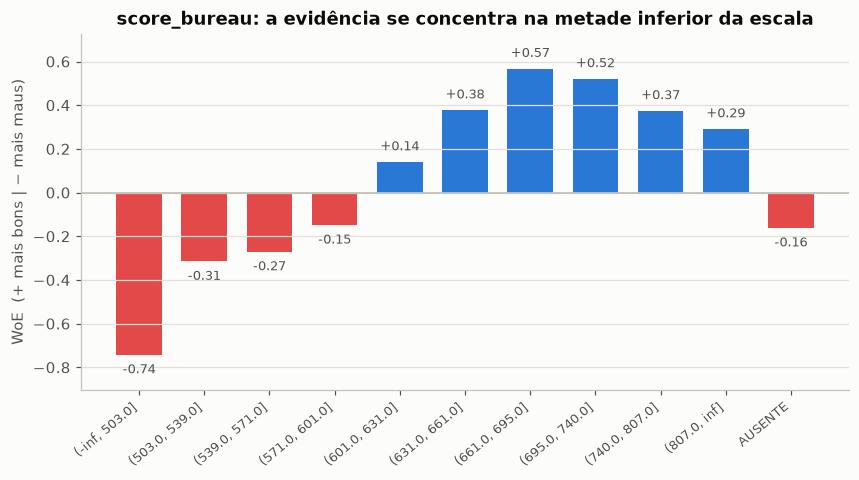

In [5]:
# WoE é uma grandeza com sinal em torno de zero -> codificação divergente:
# dois tons opostos e um meio neutro. Nunca uma rampa de arco-íris.
feat = "score_bureau"
t = tabelas[feat]
cores = [AZUL if w >= 0 else VERMELHO for w in t["woe"]]

fig, ax = plt.subplots(figsize=(9, 4.2))
ax.bar(range(len(t)), t["woe"], color=cores, width=0.7)
ax.axhline(0, color=EIXO, lw=1.2)
ax.set_xticks(range(len(t)))
ax.set_xticklabels([str(i) for i in t.index], rotation=40, ha="right", fontsize=8.5)
for i, (w, n) in enumerate(zip(t["woe"], t["n"])):
    ax.text(i, w + (0.04 if w >= 0 else -0.04), f"{w:+.2f}", ha="center",
            va="bottom" if w >= 0 else "top", fontsize=8.5, color=SECUNDARIA)
ax.set_ylim(t["woe"].min() - 0.16, t["woe"].max() + 0.16)   # folga para os rótulos
ax.set_ylabel("WoE  (+ mais bons | − mais maus)")
ax.set_title(f"{feat}: a evidência se concentra na metade inferior da escala")
ax.grid(axis="x", visible=False)
plt.show()

## `score_bureau` satura acima de 600

O gráfico acima mostra o WoE subindo forte até o meio da escala e depois **empacando**. Olhando a
inadimplência observada por faixa, com intervalo de confiança de 95%, fica claro por quê.

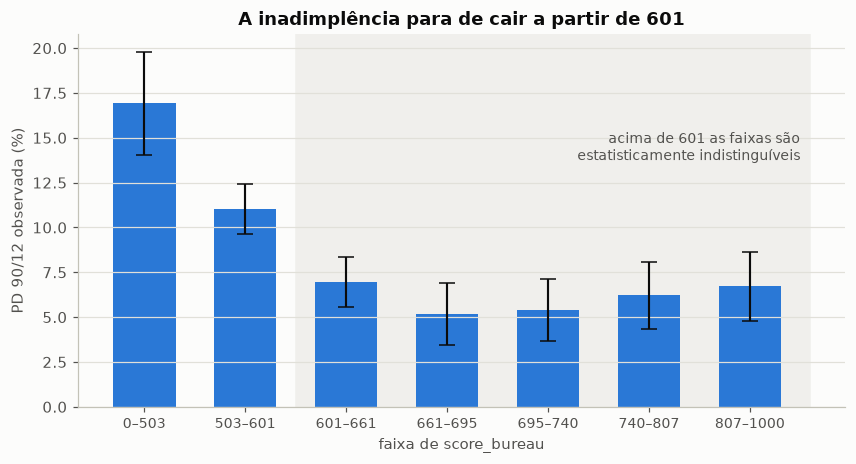

(661,695] vs (740,807]     z = +0.81   indistinguível
(661,695] vs (807,1000]    z = +1.18   indistinguível
(601,661] vs (807,1000]    z = -0.20   indistinguível


In [6]:
faixas = pd.cut(treino["score_bureau"], [0, 503, 601, 661, 695, 740, 807, 1000])
t_ic = pd_com_ic(tabela_woe(faixas.astype(str).where(treino["score_bureau"].notna(), AUSENTE),
                           treino[ALVO])).drop(index=AUSENTE, errors="ignore")
t_ic = t_ic.loc[sorted(t_ic.index, key=lambda s: float(s.split(",")[0].strip("(")))]

fig, ax = plt.subplots(figsize=(9, 4.4))
x = np.arange(len(t_ic))
ax.bar(x, t_ic["pd"] * 100, color=RAMPA_AZUL[4], width=0.62)
ax.errorbar(x, t_ic["pd"] * 100, yerr=[(t_ic["pd"] - t_ic["ic_lo"]) * 100, (t_ic["ic_hi"] - t_ic["pd"]) * 100],
            fmt="none", ecolor=TINTA, elinewidth=1.4, capsize=5)
ax.axvspan(1.5, len(x) - 0.4, color=NEUTRO, zorder=0)
ax.text(len(x) - 0.5, 15.4, "acima de 601 as faixas são\nestatisticamente indistinguíveis",
        ha="right", va="top", fontsize=9, color=SECUNDARIA)
ax.set_xticks(x)
ax.set_xticklabels([s.replace(", ", "–").strip("(]") for s in t_ic.index], fontsize=9)
ax.set_ylabel("PD 90/12 observada (%)")
ax.set_xlabel("faixa de score_bureau")
ax.set_title("A inadimplência para de cair a partir de 601")
ax.grid(axis="x", visible=False)
plt.show()

for i, j, rot in [(3, 5, "(661,695] vs (740,807]"), (3, 6, "(661,695] vs (807,1000]"),
                  (2, 6, "(601,661] vs (807,1000]")]:
    p1, n1 = t_ic["pd"].iloc[i], t_ic["n"].iloc[i]
    p2, n2 = t_ic["pd"].iloc[j], t_ic["n"].iloc[j]
    z = (p2 - p1) / np.sqrt(p1 * (1 - p1) / n1 + p2 * (1 - p2) / n2)
    print(f"{rot:<26} z = {z:+.2f}   {'indistinguível' if abs(z) < 1.96 else 'DIFERENÇA REAL'}")

A faixa 740-807 chega a marcar PD **maior** que a faixa 661-695. A tentação é anunciar a
descoberta — "clientes de score altíssimo são mais arriscados". **Os testes não sustentam isso:**
nenhuma diferença passa de |z| = 1,96.

O que os dados dizem é mais simples e mais útil: **acima de 601 o `score_bureau` não discrimina
mais nada nesta carteira.** Toda a capacidade preditiva dele está na metade inferior da escala.

*Consequência para a política:* não adianta abrir quatro faixas de score no topo com base em
bureau. A separação lá em cima, se existir, terá de vir de outras variáveis.

## Pergunta 2 — o faltante carrega informação?

A hipótese de partida é a do mercado: quem não declara renda costuma ter perfil de risco pior, e
a ausência viraria um indicador. Hipótese é para ser testada, não assumida.

In [7]:
linhas = []
for feat in ["renda_mensal_declarada", "tempo_emprego_meses", "score_bureau"]:
    m = treino[feat].isna()
    linhas.append({
        "coluna": feat, "n_ausente": int(m.sum()), "% ausente": m.mean(),
        "PD ausente": treino.loc[m, ALVO].mean(), "PD presente": treino.loc[~m, ALVO].mean(),
        "razão": treino.loc[m, ALVO].mean() / treino.loc[~m, ALVO].mean(),
    })
pd.DataFrame(linhas).style.format({
    "% ausente": "{:.2%}", "PD ausente": "{:.2%}", "PD presente": "{:.2%}", "razão": "{:.2f}x"
})

,coluna,n_ausente,% ausente,PD ausente,PD presente,razão
0,renda_mensal_declarada,509,7.63%,9.23%,8.76%,1.05x
1,tempo_emprego_meses,780,11.69%,9.74%,8.68%,1.12x
2,score_bureau,228,3.42%,10.09%,8.76%,1.15x


**A hipótese não se sustentou.** As razões ficam entre 1,05x e 1,15x, e o caso mais forte
(`score_bureau` ausente) tem apenas 228 contratos — intervalo de confiança largo o bastante para
cobrir a média geral.

**Decisão: não criar indicadores de ausência.** Imputação simples pela mediana, dentro do
pipeline. Registrar a hipótese testada e descartada vale mais que o indicador que ela teria
gerado — é exatamente a pergunta que uma área de risco faz ("como vocês trataram os faltantes?"),
e agora há resposta com número.

## Pergunta 3 — as relações são monotônicas?

Medida por Spearman entre a ordem do bin e a PD, mais a contagem de inversões de direção.

Um detalhe de implementação que vale mais que parece: os bins precisam ser **categóricas
ordenadas**. Se o rótulo da faixa vira texto, `"(1000.0, 1500.0]"` passa a ordenar **antes** de
`"(400.0, 450.0]"` — e a leitura de monotonicidade sai errada sem gerar nenhum erro.

In [8]:
num = resumo[~resumo["variável"].isin(CATEGORICAS)].sort_values("rho", key=abs, ascending=False)
num[["variável", "rho", "inversões", "monotonicidade"]].reset_index(drop=True)

,variável,rho,inversões,monotonicidade
0,qtd_restricoes_ativas,1.000000,0,monotônica
1,prazo_meses,1.000000,0,monotônica
2,qtd_consultas_bureau_3m,1.000000,0,monotônica
3,valor_bem,-0.951515,4,NÃO monotônica — agrupar por WoE
4,renda_mensal_declarada,-0.899700,5,NÃO monotônica — agrupar por WoE
5,idade_veiculo_anos,0.833333,3,aceitável
6,valor_financiado,-0.796356,6,NÃO monotônica — agrupar por WoE
7,score_bureau,-0.793939,1,monotônica
8,tempo_emprego_meses,-0.769697,7,NÃO monotônica — agrupar por WoE
9,ano_modelo,-0.738095,3,aceitável


## O achado mais grave: parte da Base C está fora do domínio de treino

`qtd_restricoes_ativas` é a segunda variável mais preditiva e perfeitamente monotônica. Repare
onde a tabela de WoE **termina**.

In [9]:
tabelas["qtd_restricoes_ativas"].assign(
    pd=lambda d: (d["pd"] * 100).round(2), woe=lambda d: d["woe"].round(3)
)[["n", "maus", "pd", "woe"]]

,n,maus,pd,woe
bin,,,,
0,3472,249,7.17,0.223
1,2159,168,7.78,0.134
2,1039,170,16.36,-0.707


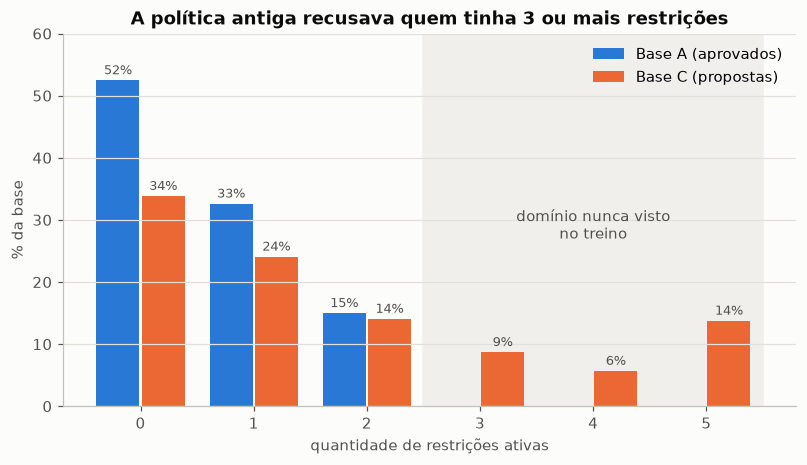

propostas da Base C acima do máximo visto em treino: 28.1% (1404 de 5000)


In [10]:
dist = pd.DataFrame({
    "Base A (aprovados)": a["qtd_restricoes_ativas"].value_counts(normalize=True),
    "Base C (propostas)": base_c["qtd_restricoes_ativas"].value_counts(normalize=True),
}).reindex(range(6)).fillna(0) * 100

fig, ax = plt.subplots(figsize=(8.6, 4.4))
x = np.arange(len(dist))
ax.bar(x - 0.20, dist["Base A (aprovados)"], width=0.38, color=AZUL, label="Base A (aprovados)")
ax.bar(x + 0.20, dist["Base C (propostas)"], width=0.38, color=LARANJA, label="Base C (propostas)")
ax.axvspan(2.5, 5.5, color=NEUTRO, zorder=0)
ax.text(4.0, 27, "domínio nunca visto\nno treino", ha="center", fontsize=9.5, color=SECUNDARIA)
ax.set_ylim(0, 60)
for i, (va, vc) in enumerate(zip(dist["Base A (aprovados)"], dist["Base C (propostas)"])):
    if va > 0:
        ax.text(i - 0.20, va + 1, f"{va:.0f}%", ha="center", fontsize=8.5, color=SECUNDARIA)
    ax.text(i + 0.20, vc + 1, f"{vc:.0f}%", ha="center", fontsize=8.5, color=SECUNDARIA)
ax.set_xticks(x)
ax.set_ylabel("% da base")
ax.set_xlabel("quantidade de restrições ativas")
ax.set_title("A política antiga recusava quem tinha 3 ou mais restrições")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
plt.show()

fora = (base_c["qtd_restricoes_ativas"] > treino["qtd_restricoes_ativas"].max()).mean()
print(f"propostas da Base C acima do máximo visto em treino: {fora:.1%} ({int(fora * len(base_c))} de {len(base_c)})")

**As bases A e B vão de 0 a 2 restrições. Só.** Isso não é coincidência: é a política antiga
impressa nos dados. A AutoCred recusava automaticamente quem tinha 3 ou mais restrições — um
corte que **não está escrito em nenhum documento do desafio** e foi recuperado do domínio da
variável.

O mesmo vale para o bureau: a Base A tem mínimo exatamente **460**, e a Base C desce até 0.

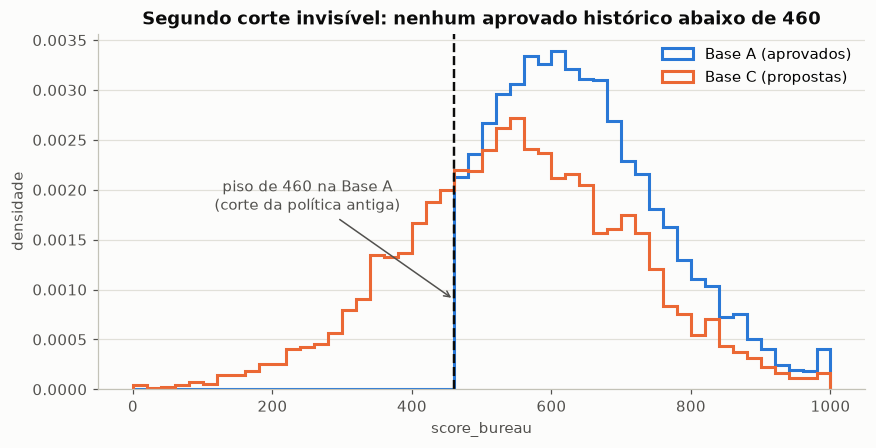

Base A: mínimo 460
Base C: mínimo 0 | abaixo de 460: 27.7%


In [11]:
# Contorno em vez de área preenchida: duas áreas translúcidas sobrepostas geram
# uma terceira cor, que o olho lê como uma terceira série que não existe.
fig, ax = plt.subplots(figsize=(9, 4.2))
bins = np.linspace(0, 1000, 51)
ax.hist(a["score_bureau"].dropna(), bins=bins, density=True, histtype="step", lw=2,
        color=AZUL, label="Base A (aprovados)")
ax.hist(base_c["score_bureau"].dropna(), bins=bins, density=True, histtype="step", lw=2,
        color=LARANJA, label="Base C (propostas)")
ax.axvline(460, color=TINTA, lw=1.6, ls="--")
ax.annotate("piso de 460 na Base A\n(corte da política antiga)", xy=(460, 0.0009),
            xytext=(250, 0.0018), ha="center", fontsize=9.5, color=SECUNDARIA,
            arrowprops=dict(arrowstyle="->", color=SECUNDARIA, lw=1))
ax.set_xlabel("score_bureau")
ax.set_ylabel("densidade")
ax.set_title("Segundo corte invisível: nenhum aprovado histórico abaixo de 460")
ax.legend(frameon=False, loc="upper right")
ax.grid(axis="x", visible=False)
plt.show()

print(f"Base A: mínimo {a['score_bureau'].min():.0f}")
print(f"Base C: mínimo {base_c['score_bureau'].min():.0f} | abaixo de 460: {(base_c['score_bureau'] < 460).mean():.1%}")

In [12]:
# Perímetro completo: em quantas propostas ao menos uma variável de crédito cai
# fora do domínio de treino. `ano_modelo` fica de fora — é deslocamento de
# calendário (propostas de 2025 têm carros mais novos), não regra de crédito.
marcas = {}
for feat in CANDIDATAS:
    if feat in CATEGORICAS or feat == "ano_modelo" or base_c[feat].notna().sum() == 0:
        continue
    lo, hi = treino[feat].min(), treino[feat].max()
    marcas[feat] = (base_c[feat] < lo) | (base_c[feat] > hi)

combinado = pd.concat(marcas.values(), axis=1).any(axis=1)
print(f"Propostas fora do domínio em ao menos uma variável: {combinado.mean():.1%} "
      f"({int(combinado.sum())} de {len(base_c)})\n")
pd.Series({k: v.mean() for k, v in marcas.items() if v.mean() > 0.01}).sort_values(
    ascending=False
).to_frame("% da Base C fora do domínio").style.format("{:.1%}")

Propostas fora do domínio em ao menos uma variável: 39.5% (1976 de 5000)



,% da Base C fora do domínio
qtd_restricoes_ativas,28.1%
score_bureau,27.7%
ltv,7.1%
valor_entrada,3.7%


### Por que isso é pior do que "menos preciso naquela região"

**Modelos baseados em árvore não extrapolam.** Um proponente com 5 restrições cai na mesma folha
de um com 2 e recebe a mesma PD, ~16%. E 2 restrições já **triplicam** a PD em relação a 1
(7,78% → 16,36%). Tratar 5 como 2 erra na direção perigosa: o modelo **subestima
sistematicamente** o risco de uma fatia grande da carteira que será decidida.

Isso não se resolve com modelagem melhor — não existe informação na base sobre quem tem 5
restrições. A alternativa de extrapolar a tendência (projetar 3, 4 e 5 a partir da inclinação
entre 1 e 2) foi descartada: seria inventar número com cara de evidência.

A saída é uma **regra de política explícita** para a região sem suporte, defendida como decisão
de risco e não como saída de modelo.

## Estabilidade de população: PSI

O **PSI** (*population stability index*) usa a mesma matemática do IV para comparar duas
populações em vez de bons contra maus. Convenção de mercado: abaixo de 0,10 estável, 0,10 a 0,25
atenção, acima de 0,25 a população trocou.

In [13]:
psi_tab = resumo.dropna(subset=["PSI_aplicacao"]).sort_values("PSI_aplicacao", ascending=False)
psi_tab = psi_tab.assign(faixa=psi_tab["PSI_aplicacao"].map(classificar_psi))
psi_tab[["variável", "PSI_aplicacao", "faixa"]].head(8).reset_index(drop=True).round(
    {"PSI_aplicacao": 3}
)

,variável,PSI_aplicacao,faixa
0,qtd_restricoes_ativas,2.335,POPULAÇÃO TROCADA
1,ano_modelo,1.394,POPULAÇÃO TROCADA
2,score_bureau,0.488,POPULAÇÃO TROCADA
3,renda_mensal_declarada,0.141,atenção
4,valor_entrada,0.111,atenção
5,ltv,0.082,estável
6,qtd_consultas_bureau_3m,0.076,estável
7,possui_avalista,0.056,estável


`qtd_restricoes_ativas` e `score_bureau` aparecem como "população trocada" — exatamente as duas
variáveis onde os cortes da política antiga foram encontrados. O PSI e o teste de domínio contam
a mesma história por caminhos diferentes, o que aumenta a confiança na leitura.

`ano_modelo` também dispara, mas por outro motivo: propostas de 2025 têm veículos mais novos que
contratos de 2022. É deslocamento de calendário, não risco — e por isso a variável sai do modelo
em vez de virar regra.

## Decisões que esta análise fecha

| Decisão | Evidência |
|---|---|
| Descartar `ano_modelo` do modelo | IV 0,013 com PSI 1,394 — artefato de calendário |
| Manter `ltv` fora do modelo, mas ativo no cálculo de risco | IV 0,017; indexa as tabelas de EAD e LGD |
| Não criar indicadores de ausência | razões de 1,05x a 1,15x, dentro do ruído |
| Imputação simples pela mediana, dentro do pipeline | corolário da decisão acima |
| Não abrir múltiplas faixas de score no topo via bureau | saturação acima de 601, |z| < 1,96 |
| Regra de política explícita para 3+ restrições | região sem nenhum suporte histórico |

As variáveis com IV abaixo de 0,02 **não** são descartadas em bloco: o IV mede relação
univariada, e o modelo escolhido (gradient boosting) aproveita variável fraca e interação. A
exceção é `ano_modelo`, descartada pela combinação de IV baixo **com** instabilidade alta.

---

*Este notebook é gerado por `notebooks/gerar_notebook.py` e consome as funções de
`src/exploracao.py` — as mesmas usadas pelo script `notebooks/01-exploracao.py`, para que
notebook e pipeline não possam divergir.*